In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
full_data = pd.read_csv("../results/reward_contributions_initial-stage.csv", index_col="Unnamed: 0")

scenarios = ["good", "med", "bad"]
dict_dfs = {}
for s in scenarios:
    dict_dfs[s] = full_data[full_data["initial_stage"] == s]

full_data.head()

,episode,week,Total_hosp,new_hosp,new_deaths,H_term,D_term,Lockdown_term,reward,action,delta,k0,error,initial_stage
0,0,10,28.523979,50.848712,7.291374,50.848712,7.291374,276.612364,-334.752450,94,0.0,0.0,False,good
1,0,12,39.136928,41.288356,9.567448,41.288356,9.567448,441.466154,-492.321958,84,0.7,0.7,False,good
2,0,14,29.878486,18.131804,6.019607,18.131804,6.019607,283.747165,-307.898576,88,0.8,0.0,False,good
3,0,16,17.901470,5.892229,3.353829,5.892229,3.353829,478.250293,-487.496350,64,0.5,0.9,False,good
4,0,18,9.278614,0.839305,0.770483,0.839305,0.770483,346.532590,-348.142379,3,0.0,0.3,False,good


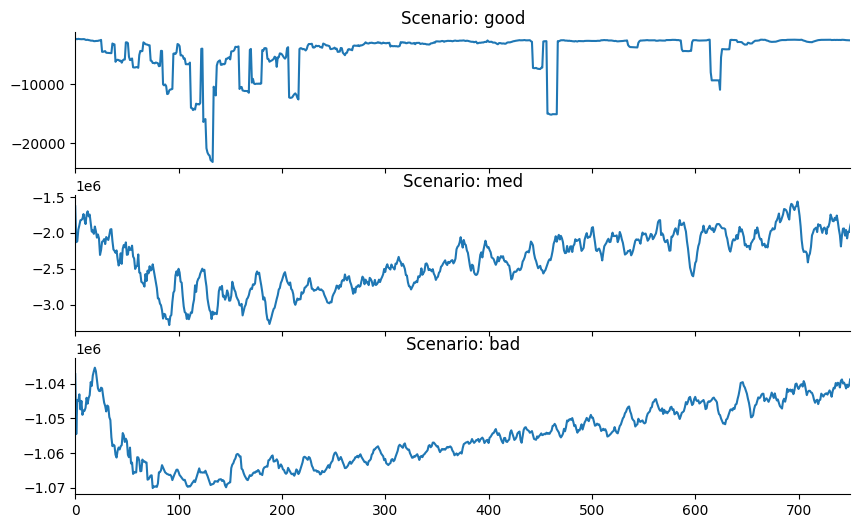

In [7]:
window = 10
xlim = (0, 750)
fig, axes = plt.subplots(3,1,figsize=(10,6), sharex=True)

for i in range(3):
    initial_stage = scenarios[i]
    df = dict_dfs[initial_stage]
    
    total_reward = (df[["episode", "reward"]]
                    .groupby("episode")
                    .sum("reward")
                    .reset_index()
                    .drop("episode", axis=1)
                    .rolling(min_periods=1, window=window)
                    .mean()
                   )
    ax = axes[i]
    ax.plot(total_reward)
    ax.set_title(f"Scenario: {initial_stage}")
    ax.set_xlim(xlim)

sns.despine()

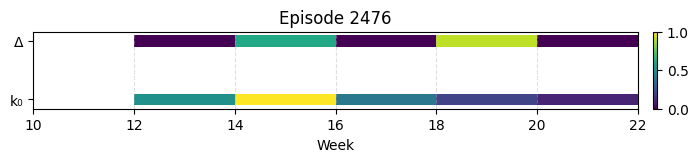

In [72]:
top = 3
episodes = df["episode"].unique()[-(top+1):-1]

for i in episodes:
    aux = df[df["episode"] == i]

aux["delta"]

ep = episodes[0]
aux = df[df["episode"] == ep].sort_values("week")

weeks = aux["week"].values
delta = aux["delta"].values
k0 = aux["k0"].values

# Normalize the values to [0,1] for consistent color mapping if needed
cmap = plt.cm.viridis

fig, ax = plt.subplots(1,1,figsize=(10,1))

# Draw horizontal bars: one for delta, one for k0
ax.barh(y=1, width=np.diff(weeks, prepend=weeks[0]), left=weeks, color=cmap(delta), height=0.2, label='Δ (social distancing)')
ax.barh(y=0, width=np.diff(weeks, prepend=weeks[0]), left=weeks, color=cmap(k0), height=0.2, label='k₀ (mobility)')

# Aesthetic adjustments
ax.set_yticks([0, 1])
ax.set_yticklabels(["k₀", "Δ"])
ax.set_title(f"Episode {ep}")
ax.set_xlabel("Week")
ax.set_xlim(min(weeks), max(weeks) + 2)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
fig.colorbar(sm, ax=ax,  fraction=0.2, pad=0.02)


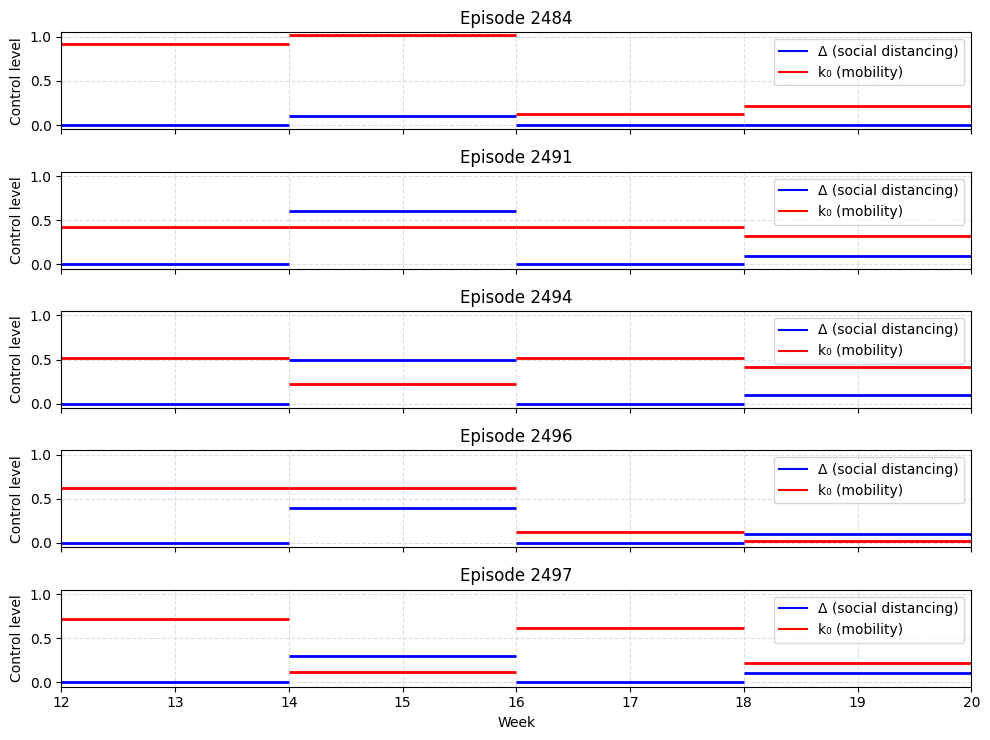

In [113]:
scenario = "med"

df = dict_dfs[scenario]


top = 5
episodes = df["episode"].unique()[-(top+1):-1]

fig, axes = plt.subplots(len(episodes), 1, figsize=(10, 1.5 * len(episodes)), sharex=True)

if len(episodes) == 1:
    axes = [axes]

for ax, ep in zip(axes, episodes):
    aux = df[df["episode"] == ep].sort_values("week")
    weeks = aux["week"].values
    delta = aux["delta"].values
    k0 = aux["k0"].values

    # Compute segment start and end points
    for i in range(len(weeks) - 1):
        ax.hlines(delta[i], weeks[i], weeks[i+1], colors='blue', linewidth=2)
        ax.hlines(k0[i]+ 0.02, weeks[i], weeks[i+1], colors='red', linewidth=2)

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(min(weeks)+2, max(weeks))
    ax.set_ylabel("Control level")
    ax.set_title(f"Episode {ep}")
    ax.grid(True, linestyle='--', alpha=0.4)

    # Add legend manually
    ax.plot([], [], color='blue', label='Δ (social distancing)')
    ax.plot([], [], color='red', label='k₀ (mobility)')
    ax.legend(loc='upper right')

axes[-1].set_xlabel("Week")

plt.tight_layout()
plt.show()


In [122]:
top = 30
episodes = df["episode"].unique()[-(top+1):-1]
all_features = []
episode_ids = []

common_weeks = np.arange(df["week"].min(), df["week"].max() + 1, 1)

for ep in episodes:
    aux = df[df["episode"] == ep].sort_values("week")

    delta_interp = np.interp(common_weeks, aux["week"], aux["delta"])
    k0_interp = np.interp(common_weeks, aux["week"], aux["k0"])

    feature_vec = np.concatenate([delta_interp, k0_interp])
    all_features.append(feature_vec)
    episode_ids.append(ep)

X = np.vstack(all_features)


# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

n_clusters = 6  # number of clusters to try
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_scaled)

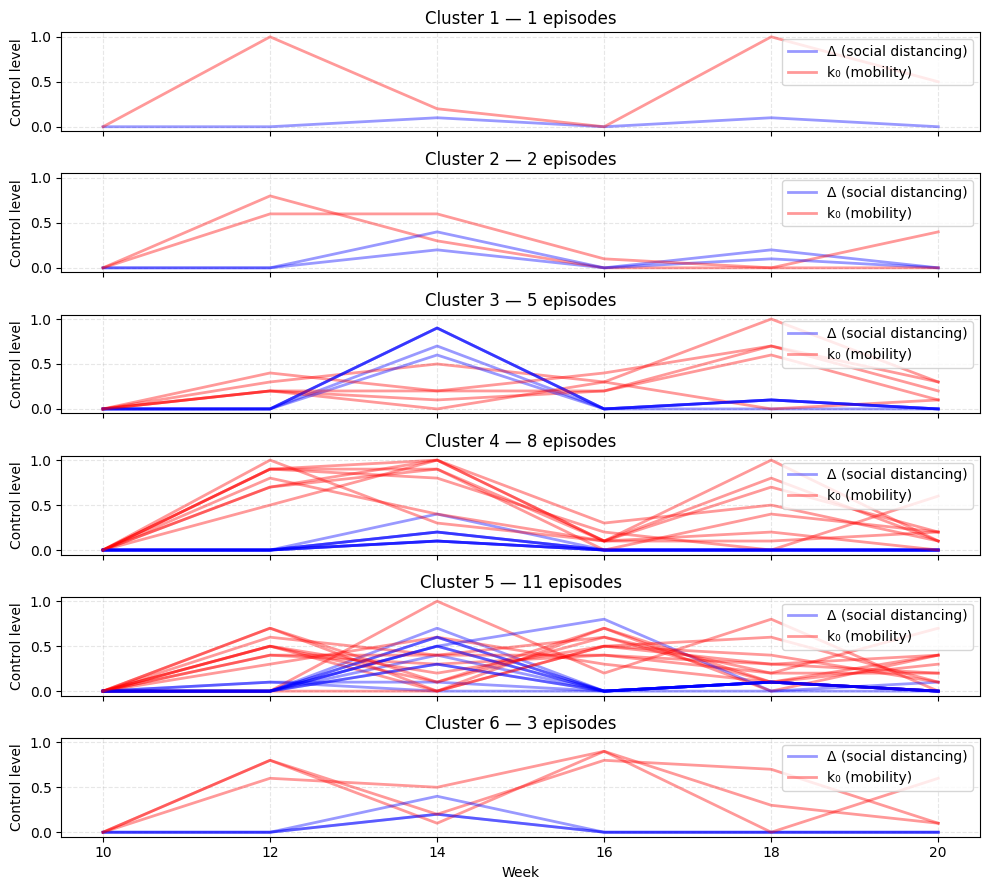

<Figure size 640x480 with 0 Axes>

In [123]:
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 1.5*n_clusters), sharex=True, sharey=True)
if n_clusters == 1:
    axes = [axes]

for i in range(n_clusters):
    members = np.where(labels == i)[0]
    ax = axes[i]
    for idx in members:
        ep = episode_ids[idx]
        aux = df[df["episode"] == ep].sort_values("week")
        ax.plot(aux["week"], aux["delta"], color='blue', alpha=0.4, linewidth=2)
        ax.plot(aux["week"], aux["k0"], color='red', alpha=0.4, linewidth=2)

    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"Cluster {i+1} — {len(members)} episodes")
    ax.set_ylabel("Control level")
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(['Δ (social distancing)', 'k₀ (mobility)'], loc='upper right')

axes[-1].set_xlabel("Week")

plt.tight_layout()
plt.show()
sns.despine()

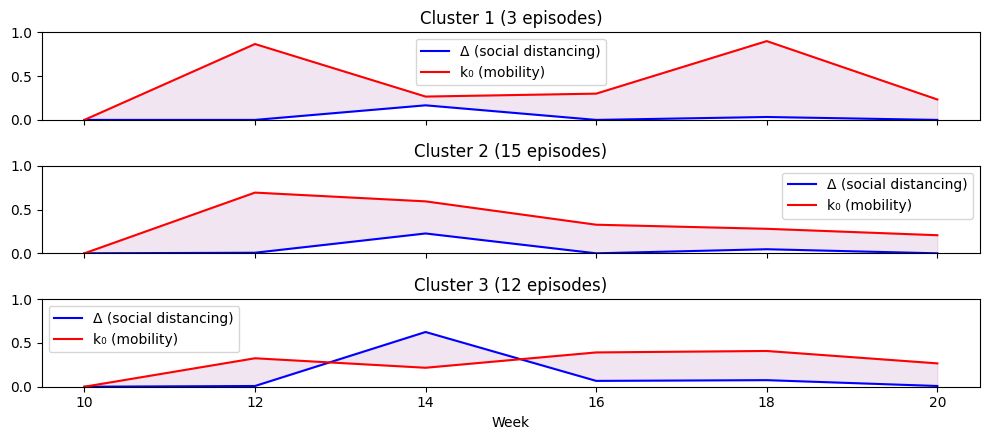

In [119]:
fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 1.5*n_clusters), sharex=True)
if n_clusters == 1: axes = [axes]

for i in range(n_clusters):
    members = X[labels == i]
    mean_delta = members[:, :len(common_weeks)].mean(axis=0)
    mean_k0 = members[:, len(common_weeks):].mean(axis=0)
    
    ax = axes[i]
    ax.plot(common_weeks, mean_delta, color='blue', label='Δ (social distancing)')
    ax.plot(common_weeks, mean_k0, color='red', label='k₀ (mobility)')
    ax.fill_between(common_weeks, mean_delta, mean_k0, color='purple', alpha=0.1)
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster {i+1} ({(labels==i).sum()} episodes)")
    ax.legend()

axes[-1].set_xlabel("Week")
plt.tight_layout()
plt.show()


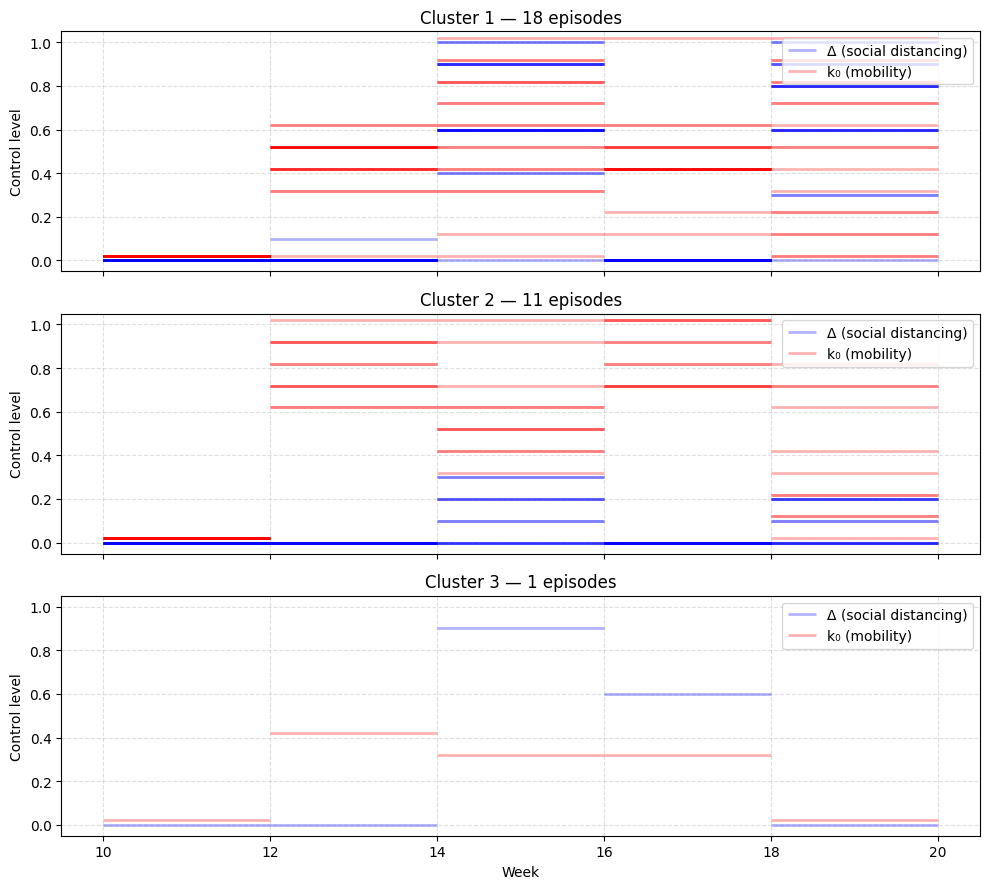

In [100]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# --- Plot per cluster ---
fig, axes = plt.subplots(k, 1, figsize=(10, 3 * k), sharex=True)
if k == 1:
    axes = [axes]

for i in range(k):
    cluster_eps = np.array(episode_ids)[labels == i]
    ax = axes[i]

    for ep in cluster_eps:
        aux = df[df["episode"] == ep].sort_values("week")
        weeks = aux["week"].values
        delta = aux["delta"].values
        k0 = aux["k0"].values

        # Plot as horizontal lines (piecewise-constant)
        for j in range(len(weeks) - 1):
            ax.hlines(delta[j], weeks[j], weeks[j+1], colors='blue', alpha=0.3, linewidth=2)
            ax.hlines(k0[j] + 0.02, weeks[j], weeks[j+1], colors='red', alpha=0.3, linewidth=2)

    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel("Control level")
    ax.set_title(f"Cluster {i+1} — {len(cluster_eps)} episodes")
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(['Δ (social distancing)', 'k₀ (mobility)'], loc='upper right')

axes[-1].set_xlabel("Week")

plt.tight_layout()
plt.show()